In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import warnings 
warnings.filterwarnings("ignore")

In [17]:
df = pd.read_csv("../data/raw/amazon_sales_dataset.csv")

In [18]:
print(df.head())

  order_id  order_date   ship_date delivery_date order_status customer_id  \
0   A10000  2026-01-31  2026-01-31    2026-01-08    Delivered       C5691   
1   A10001  2026-01-20  2026-02-03    2026-02-03    Delivered       C9811   
2   A10002  2026-01-15  2026-02-07    2026-01-03    Delivered       C7341   
3   A10003  2026-01-18  2026-01-15    2026-01-20    Delivered       C4012   
4   A10004  2026-01-27  2026-01-04    2026-01-23    Delivered       C1328   

        customer_name country           state                 city  ...  \
0        Ricky Potter   India  South Carolina              New Joe  ...   
1     Chris Davenport   India       Tennessee         Madisonmouth  ...   
2   Timothy Gallagher   India            Iowa       East Larryberg  ...   
3      Angela Collins   India        Kentucky  South Margaretshire  ...   
4  David Davidson DDS   India    North Dakota        Velasquezview  ...   

  product_name     category sub_category                        brand  \
0      withou

In [19]:
df.to_csv("../data/processed/cleaned_amazon_sales_dataset.csv", index=False)

In [ ]:
df.describe()

,quantity,unit_price,discount,shipping_cost,total_sales
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.01440,25126.511133,0.149968,85.053192,64212.910555
std,1.42035,14343.922332,0.086828,37.575284,50992.635082
min,1.00000,214.200000,0.000000,20.010000,309.939600
25%,2.00000,12657.827500,0.070000,52.507500,24037.196775
50%,3.00000,24880.490000,0.150000,84.995000,50287.177500
75%,4.00000,37544.640000,0.220000,117.680000,93417.891825
max,5.00000,49981.880000,0.300000,149.950000,249155.530000


In [ ]:
date_columns = ['order_date','ship_date','delivery_date']
for col in date_columns:
    df[col]=pd.to_datetime(df[col])

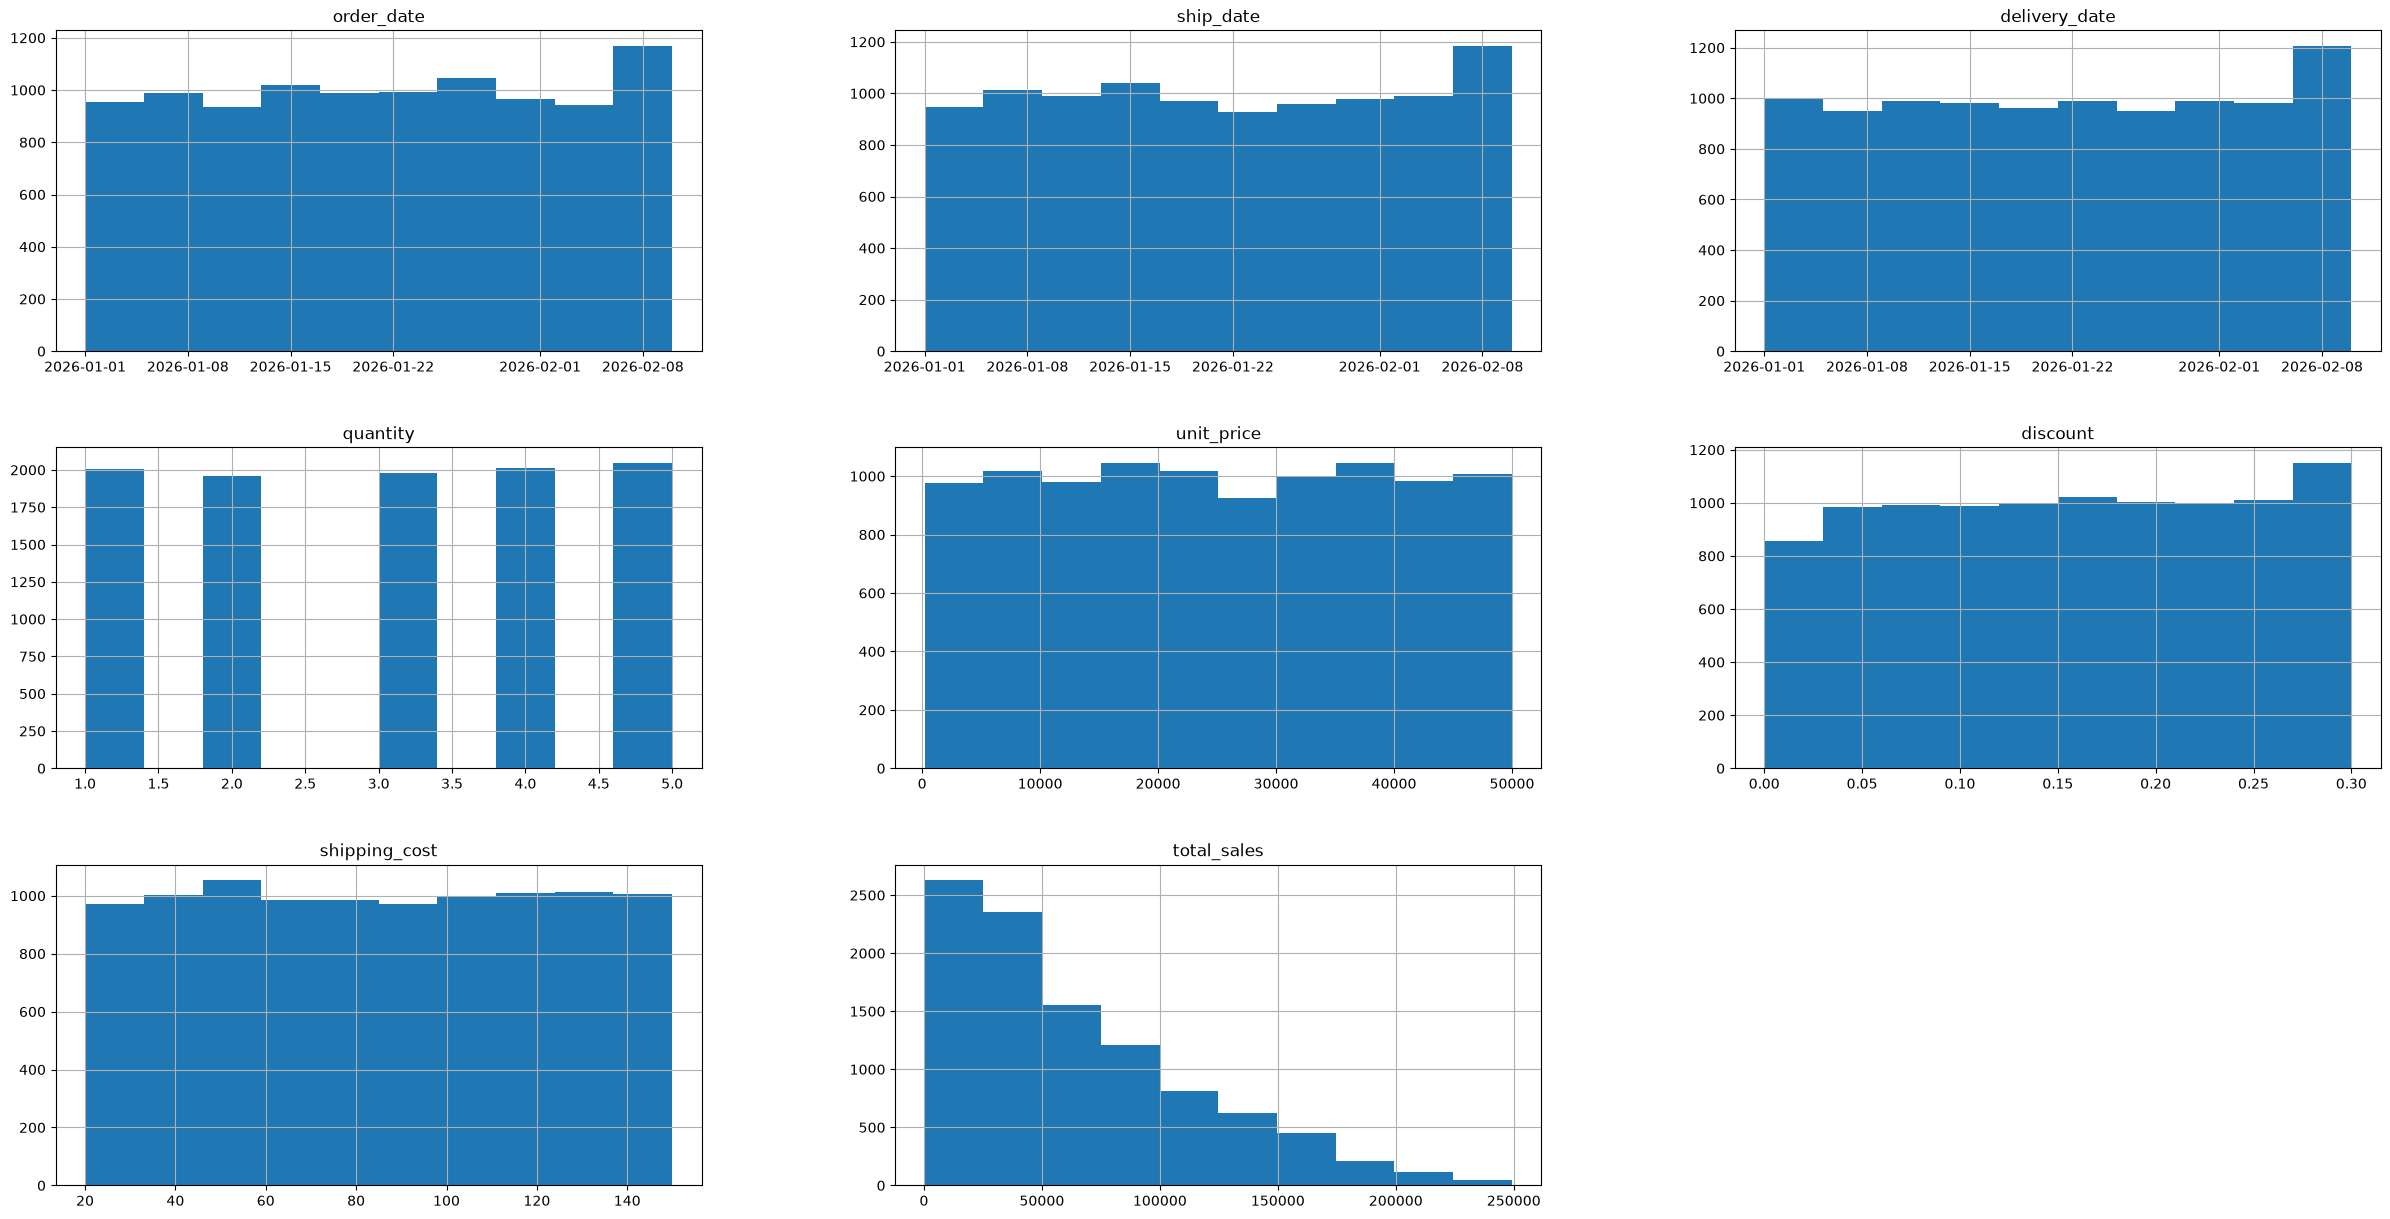

In [ ]:
df.hist(figsize=(30,15))
plt.show()

# Total Sales by Category

In [ ]:
category_sales = round(df.groupby("category")["total_sales"].sum())
category_sales

category
Electronics    219356275.0
Fashion        208009065.0
Home           214763766.0
Name: total_sales, dtype: float64

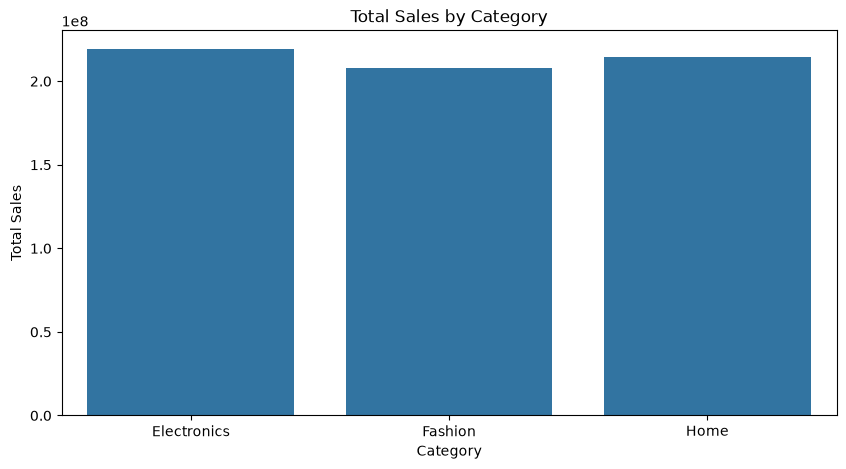

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# Top 10 Products

In [ ]:
top_products = round(df.groupby("product_name")["total_sales"].sum().nlargest(10))
top_products

product_name
maintain    2096518.0
include     1930786.0
trouble     1711159.0
suffer      1629241.0
will        1590366.0
trade       1539003.0
big         1470008.0
cut         1466105.0
many        1450177.0
level       1404670.0
Name: total_sales, dtype: float64

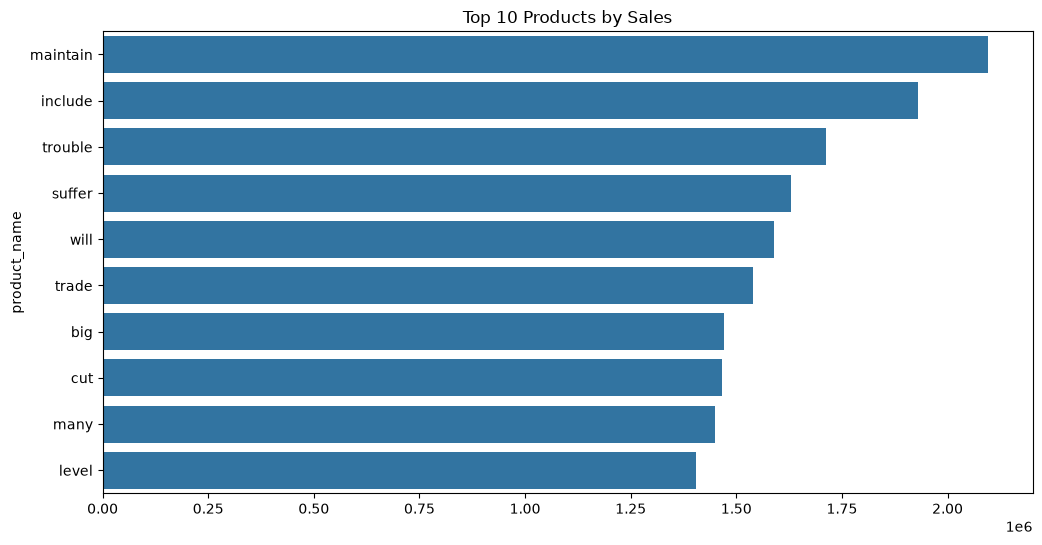

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")
plt.show()

# Sales by Payment Method

In [ ]:
payment_sales = round(df.groupby("payment_method")["total_sales"].sum())
payment_sales

payment_method
COD           163729795.0
Card          161282173.0
NetBanking    158295333.0
UPI           158821805.0
Name: total_sales, dtype: float64

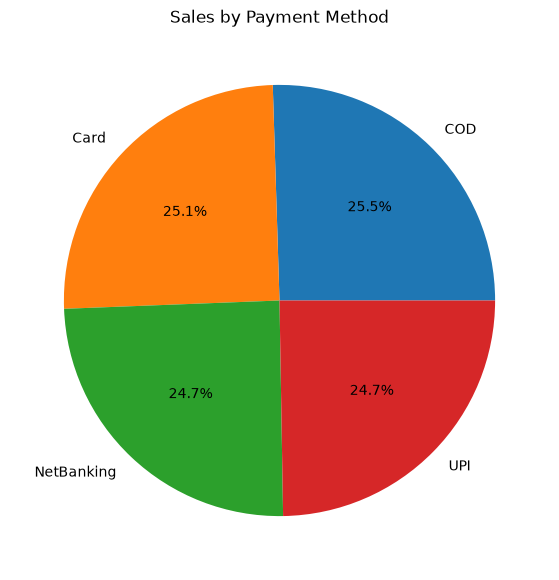

In [ ]:
payment_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Sales by Payment Method")
plt.show()

# Sales by State

In [ ]:
state_sales =round(df.groupby("state")["total_sales"].sum())
state_sales.head(10)

state
Alabama        13104947.0
Alaska         13711246.0
Arizona        14709889.0
Arkansas       14207029.0
California     11829574.0
Colorado       11942480.0
Connecticut    14106743.0
Delaware       13607495.0
Florida        12787015.0
Georgia        11726620.0
Name: total_sales, dtype: float64

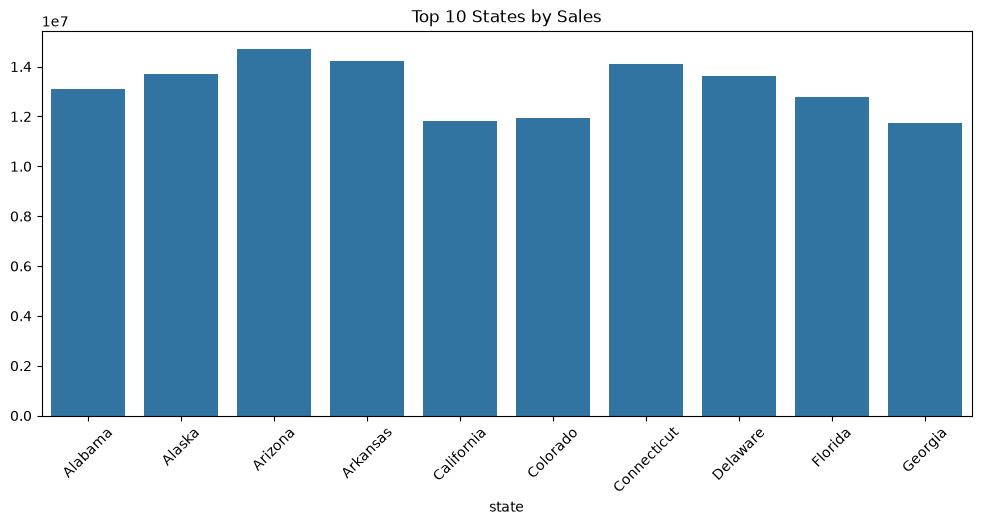

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=state_sales.head(10).index,
    y=state_sales.head(10).values
)

plt.title("Top 10 States by Sales")
plt.xticks(rotation=45)
plt.show()

# Sales by City

In [ ]:
city_sales = df.groupby("city")["total_sales"].sum().nlargest(10)
city_sales

city
Lake Michael     806828.2421
Lisamouth        744145.7698
Lake David       690903.0536
Port Michael     680444.4291
Lake Steven      675981.3863
East Jennifer    652775.9407
Williamsbury     643689.3017
Johnsonmouth     602667.3245
Port David       593138.5684
Lake Anthony     583066.1000
Name: total_sales, dtype: float64

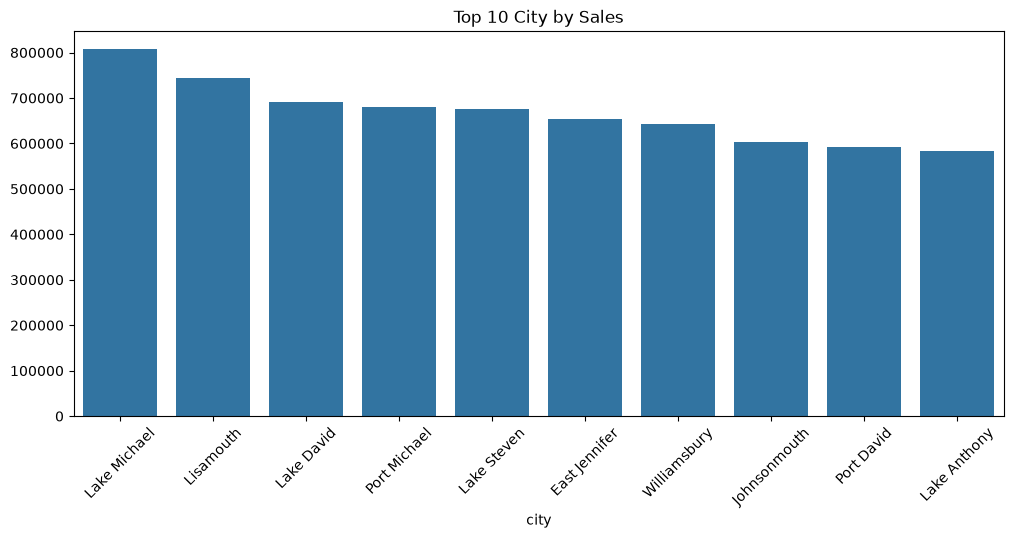

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=city_sales.head(10).index,
    y=city_sales.head(10).values
)

plt.title("Top 10 City by Sales")
plt.xticks(rotation=45)
plt.show()

# Discount Analysis

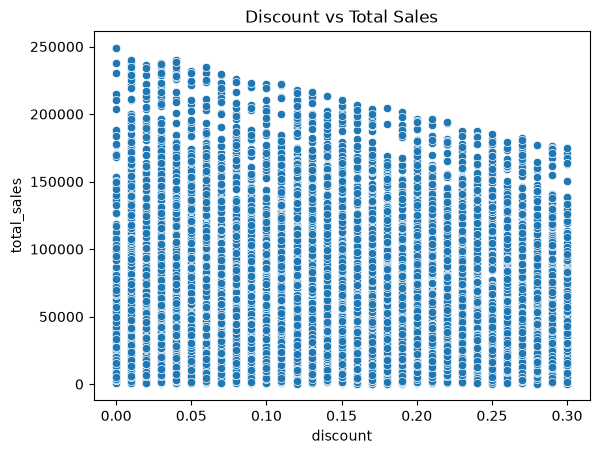

In [ ]:
sns.scatterplot(
    x="discount",
    y="total_sales",
    data=df
)

plt.title("Discount vs Total Sales")
plt.show()

# Monthly Sales 

In [ ]:
df["Month"] = df["order_date"].dt.month_name()

In [ ]:
monthly_sales = round(df.groupby("Month")["total_sales"].sum())

monthly_sales

Month
February    152138992.0
January     489990114.0
Name: total_sales, dtype: float64

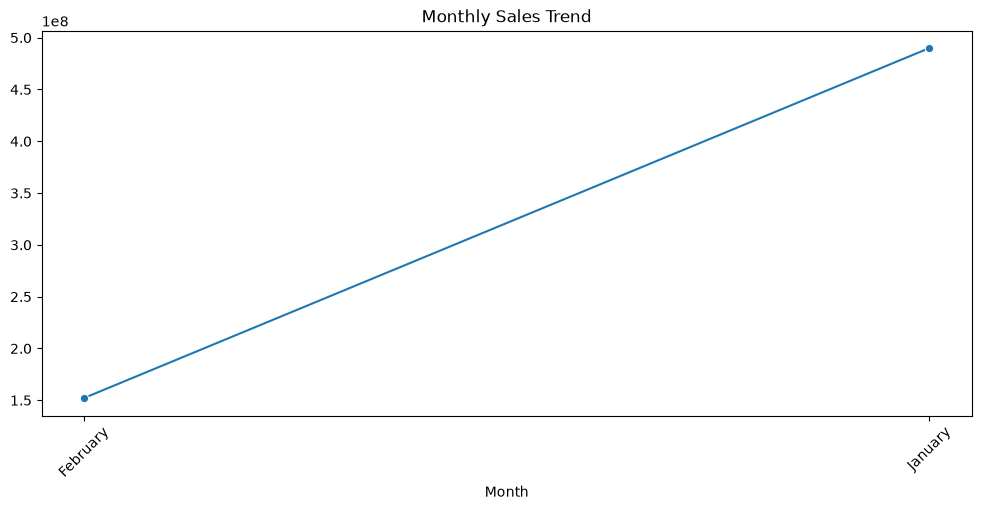

In [ ]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.show()

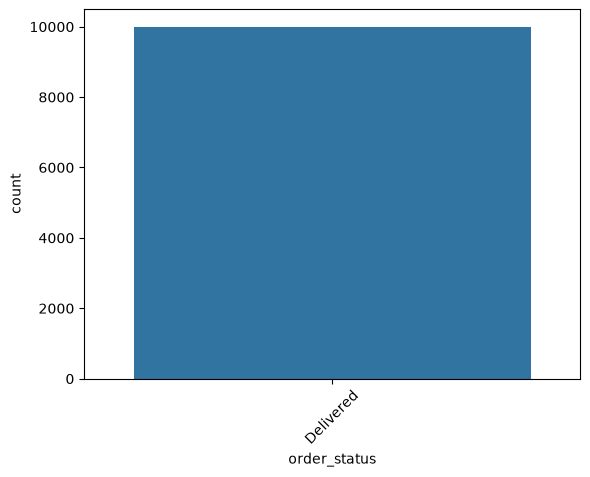

In [ ]:
sns.countplot(
    x="order_status",
    data=df
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
brand_sales = round(df.groupby("brand")["total_sales"].sum().sort_values(ascending=False))

brand_sales.head(10)

brand
Johnson and Sons     1185207.0
Smith Ltd            1178539.0
Smith and Sons       1011521.0
Jones and Sons        996323.0
Martinez and Sons     957548.0
Williams LLC          915010.0
Smith LLC             904596.0
Jones Inc             863571.0
Martinez PLC          815887.0
Brown Group           797493.0
Name: total_sales, dtype: float64

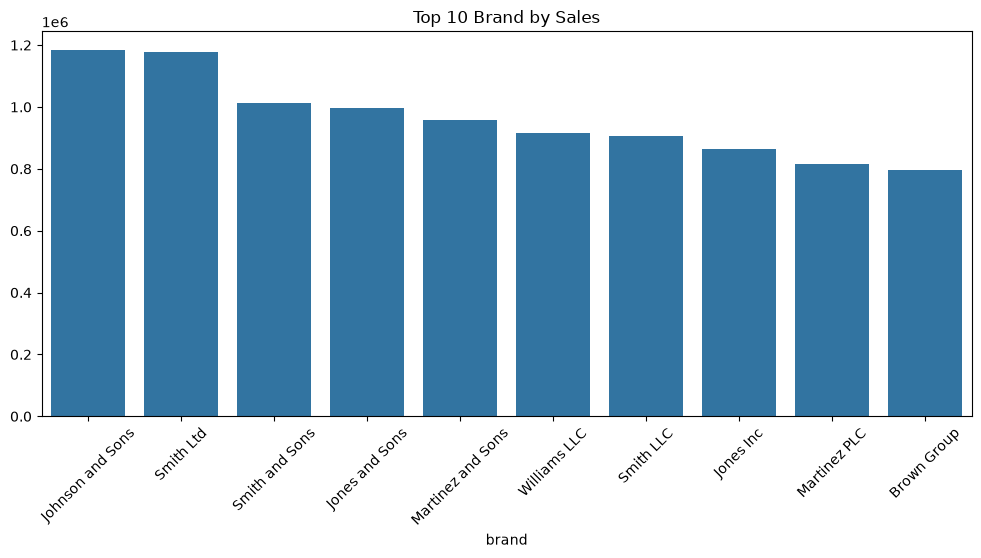

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=brand_sales.head(10).index,
    y=brand_sales.head(10).values
)

plt.title("Top 10 Brand by Sales")
plt.xticks(rotation=45)
plt.show()

# Data Cleaning

In [ ]:
df["delivery_days"] = (df["delivery_date"] - df["ship_date"]).dt.days

In [ ]:
df["order_month"] = df["order_date"].dt.month_name()

In [ ]:
df["order_year"] = df["order_date"].dt.year

In [ ]:
df["order_day"] = df["order_date"].dt.day_name()

In [ ]:
df.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,unit_price,discount,shipping_cost,total_sales,payment_method,Month,delivery_days,order_month,order_year,order_day
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,42467.79,0.26,60.85,94339.3438,Card,January,-23,January,2026,Saturday
1,A10001,2026-01-20,2026-02-03,2026-02-03,Delivered,C9811,Chris Davenport,India,Tennessee,Madisonmouth,...,36138.76,0.24,112.96,55043.8752,COD,January,0,January,2026,Tuesday
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,47148.93,0.14,64.11,162256.4292,UPI,January,-35,January,2026,Thursday
3,A10003,2026-01-18,2026-01-15,2026-01-20,Delivered,C4012,Angela Collins,India,Kentucky,South Margaretshire,...,18487.99,0.06,114.15,17492.8606,Card,January,5,January,2026,Sunday
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,1742.25,0.10,40.47,1608.4950,UPI,January,19,January,2026,Tuesday


In [21]:
invalid_dates = df[df['delivery_date'] < df['order_date']]
invalid_dates.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
0,A10000,2026-01-31,2026-01-31,2026-01-08,Delivered,C5691,Ricky Potter,India,South Carolina,New Joe,...,without,Home,Furniture,Doyle-Jordan,3,42467.79,0.26,60.85,94339.3438,Card
2,A10002,2026-01-15,2026-02-07,2026-01-03,Delivered,C7341,Timothy Gallagher,India,Iowa,East Larryberg,...,I,Electronics,Laptop,Watson and Sons,4,47148.93,0.14,64.11,162256.4292,UPI
4,A10004,2026-01-27,2026-01-04,2026-01-23,Delivered,C1328,David Davidson DDS,India,North Dakota,Velasquezview,...,bit,Home,Kitchen,"Key, Bautista and Bowen",1,1742.25,0.10,40.47,1608.4950,UPI
7,A10007,2026-02-07,2026-02-01,2026-01-10,Delivered,C2638,Elizabeth Thornton,India,Georgia,Ricemouth,...,choice,Home,Furniture,Johns-Kelly,4,21118.07,0.19,61.18,68483.7268,COD
8,A10008,2026-02-09,2026-02-03,2026-01-01,Delivered,C4823,Theresa Collins,India,Maryland,Coreystad,...,like,Electronics,Mobile,"Silva, White and Bates",5,12891.02,0.03,99.08,62620.5270,COD


In [22]:
df = df[df['delivery_date'] >= df['order_date']]

In [23]:
invalid_dates = df[df['delivery_date'] < df['order_date']]
invalid_dates.head()

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method


In [29]:
df = df[df['ship_date'] >= df['order_date']]

In [30]:
df[df['ship_date'] < df['order_date']]

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method


In [32]:
df[df['delivery_date'] < df['ship_date']]

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method
5,A10005,2026-01-05,2026-01-12,2026-01-11,Delivered,C9019,Lauren Russell,India,South Carolina,Ryanburgh,...,through,Home,Furniture,Lee Inc,3,12618.95,0.22,105.47,29633.8130,Card
12,A10012,2026-01-15,2026-01-24,2026-01-20,Delivered,C1171,Kyle Fuller,India,Texas,North Jordan,...,firm,Home,Kitchen,Leblanc LLC,1,49691.03,0.02,60.57,48757.7794,COD
17,A10017,2026-01-01,2026-02-08,2026-01-20,Delivered,C5554,Mark Roberts,India,Oklahoma,Mariafort,...,themselves,Home,Kitchen,Steele-Butler,2,12575.81,0.06,27.80,23670.3228,Card
34,A10034,2026-01-14,2026-02-04,2026-01-17,Delivered,C5483,Christine Hartman,India,Texas,South Samanthaside,...,authority,Home,Furniture,Adkins Inc,4,49095.73,0.06,100.78,184700.7248,Card
45,A10045,2026-01-07,2026-02-04,2026-01-09,Delivered,C5749,Tiffany Simpson PhD,India,Pennsylvania,Smithfort,...,then,Home,Furniture,Wilson-Benson,2,48196.22,0.03,50.84,93551.5068,NetBanking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9960,A19960,2026-01-05,2026-02-07,2026-02-05,Delivered,C1712,Carolyn Torres,India,Arizona,Andersonton,...,environmental,Home,Kitchen,Park Inc,1,25217.87,0.12,115.30,22307.0256,UPI
9961,A19961,2026-01-05,2026-01-20,2026-01-07,Delivered,C7463,Joshua Garcia,India,Oregon,New Carol,...,program,Home,Kitchen,"French, Atkinson and Sutton",2,25934.27,0.03,120.73,50433.2138,NetBanking
9977,A19977,2026-01-15,2026-02-01,2026-01-26,Delivered,C3430,Charles Wilson,India,Missouri,New Lisahaven,...,even,Electronics,Laptop,"Green, Sanchez and Smith",3,30770.25,0.20,73.76,73922.3600,Card
9978,A19978,2026-01-27,2026-02-07,2026-02-05,Delivered,C3831,Linda Taylor,India,North Dakota,Port Stephanie,...,concern,Home,Furniture,"Williams, Wagner and Gross",1,33133.58,0.25,138.84,24989.0250,COD


In [33]:
df = df[df['delivery_date'] >= df['ship_date']]

In [34]:
df[df['delivery_date'] < df['ship_date']]

,order_id,order_date,ship_date,delivery_date,order_status,customer_id,customer_name,country,state,city,...,product_name,category,sub_category,brand,quantity,unit_price,discount,shipping_cost,total_sales,payment_method


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.dtypes

order_id              str
order_date            str
ship_date             str
delivery_date         str
order_status          str
customer_id           str
customer_name         str
country               str
state                 str
city                  str
product_id            str
product_name          str
category              str
sub_category          str
brand                 str
quantity            int64
unit_price        float64
discount          float64
shipping_cost     float64
total_sales       float64
payment_method        str
dtype: object

In [28]:
df.describe()

,quantity,unit_price,discount,shipping_cost,total_sales
count,5089.000000,5089.000000,5089.000000,5089.000000,5089.000000
mean,3.030261,25238.134075,0.148764,85.520318,65357.865943
std,1.415140,14389.948683,0.086676,37.680856,51930.860625
min,1.000000,216.910000,0.000000,20.010000,357.791600
25%,2.000000,12676.890000,0.070000,52.560000,23839.372800
50%,3.000000,25169.820000,0.150000,86.060000,51545.138400
75%,4.000000,37702.100000,0.220000,118.230000,95417.259600
max,5.000000,49981.880000,0.300000,149.950000,249155.530000


In [37]:
df.to_csv("../data/processed/cleaned_amazon_sales_dataset.csv", index=False)